<a href="https://colab.research.google.com/github/Jason-Youu/generative_agents/blob/main/%E4%B8%89%E7%BB%B4%E5%90%91%E9%87%8F%E5%9C%BA%E4%B8%8E%E7%BB%88%E7%82%B9%E8%BD%A8%E8%BF%B9%E5%8F%AF%E8%A7%86%E5%8C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

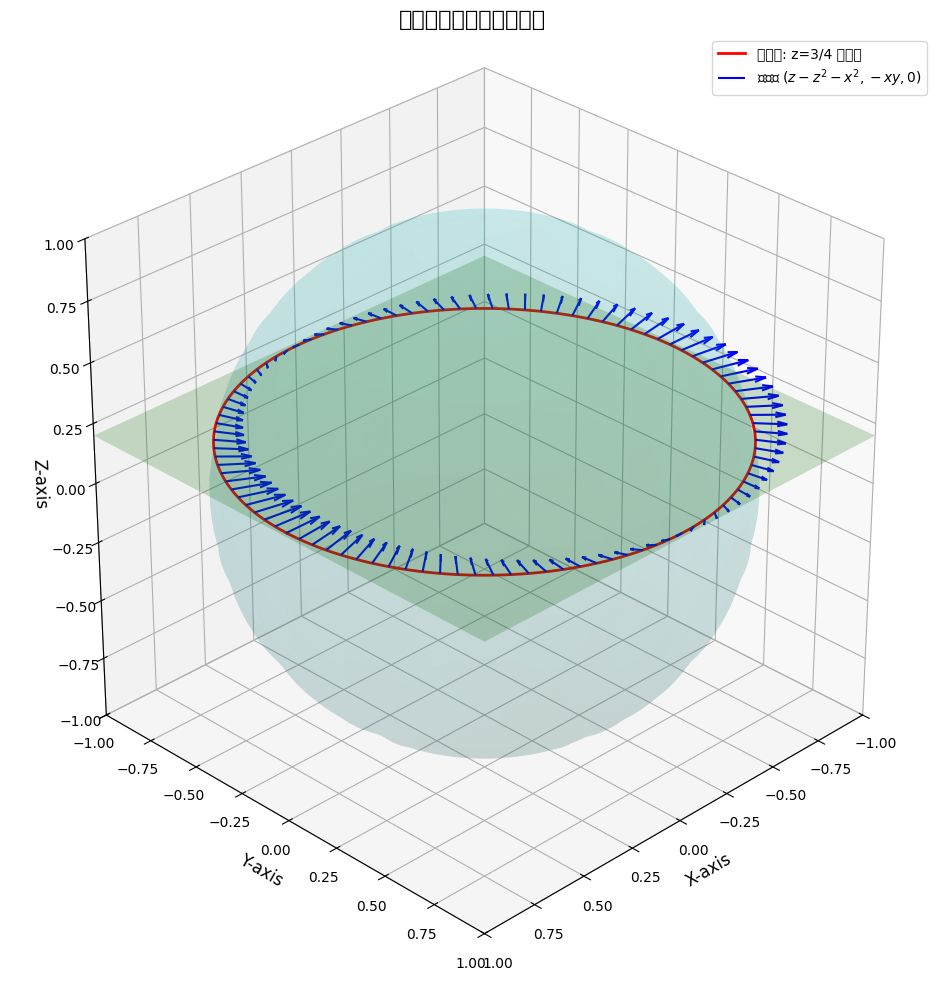

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. 创建三维绘图环境 ---
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# --- 2. 绘制单位球面 (Unit Sphere) ---
# 生成球面的参数坐标 u, v
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)
# 计算球面的笛卡尔坐标
sphere_x = np.outer(np.cos(u), np.sin(v))
sphere_y = np.outer(np.sin(u), np.sin(v))
sphere_z = np.outer(np.ones(np.size(u)), np.cos(v))
# 绘制半透明的球面
ax.plot_surface(sphere_x, sphere_y, sphere_z, color='c', alpha=0.1, rstride=4, cstride=4)

# --- 3. 绘制平面 z = 3/4 ---
z_plane_val = 0.2
# 创建一个网格来表示平面
plane_xx, plane_yy = np.meshgrid(np.linspace(-1, 1, 10), np.linspace(-1, 1, 10))
plane_zz = np.full_like(plane_xx, z_plane_val)
# 绘制半透明的平面
ax.plot_surface(plane_xx, plane_yy, plane_zz, color='g', alpha=0.2)


# --- 4. 绘制交集圆 (Intersection Circle) ---
# 这是向量场的定义域
# 计算圆的半径 r^2 = 1 - z^2
radius = np.sqrt(1 - z_plane_val**2)
theta = np.linspace(0, 2 * np.pi, 200)
# 计算圆上点的三维坐标
circle_x = radius * np.cos(theta)
circle_y = radius * np.sin(theta)
circle_z = np.full_like(theta, z_plane_val)
# 绘制红色的圆
ax.plot(circle_x, circle_y, circle_z, color='r', linewidth=2, label='定义域: z=3/4 处的圆')


# --- 5. 计算并绘制向量场 (Vector Field) ---
# 在圆上选择一些点作为向量的起点
num_vectors = 100
theta_vec = np.linspace(0, 2 * np.pi, num_vectors, endpoint=False)
# 向量起点的三维坐标
x_start = radius * np.cos(theta_vec)
y_start = radius * np.sin(theta_vec)
z_start = np.full_like(theta_vec, z_plane_val)

# 计算向量的分量 V = (Vx, Vy, Vz)
# V = (z - z^2 - x^2, -xy, 0)
Vx =  (z_plane_val - z_plane_val**2 - x_start**2)
Vy = -  x_start * y_start
Vz =  np.zeros_like(x_start) # 向量平行于 xy 平面

# 使用 quiver 绘制三维向量
ax.quiver(x_start, y_start, z_start, Vx, Vy, Vz,
          length=0.2, normalize=False, color='b',
          label='向量场 $(z-z^2-x^2, -xy, 0)$')



# --- 7. 格式化图形 ---
ax.set_title('三维向量场及其终点轨迹', fontsize=16)
ax.set_xlabel('X-axis', fontsize=12)
ax.set_ylabel('Y-axis', fontsize=12)
ax.set_zlabel('Z-axis', fontsize=12)

# 设置坐标轴范围和比例，使图形看起来更匀称
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])
ax.set_box_aspect([1,1,1]) # Matplotlib 3.3+ for equal aspect ratio

# 调整视角
ax.view_init(elev=30, azim=45)

# 添加图例
ax.legend()

# 显示图形
plt.show()